# TASK NO 1
# Iris Flower Species Classification using Machine Learning

This notebook uses measurements of Iris flowers to train a machine learning model that predicts the species:

- **Setosa**
- **Versicolor**
- **Virginica**

The goal is to understand a basic **classification** problem in machine learning using the famous Iris dataset from **Scikit-learn**.


## 1. What is Classification?

Classification is a type of supervised machine learning where the model learns from labeled examples.

In this project:

- **Input features** are flower measurements such as sepal length, sepal width, petal length, and petal width.
- **Target labels** are the Iris flower species.
- The model learns patterns from training data.
- Then it predicts the species of new flowers using test data.


## 2. Import Required Libraries

In [1]:
# Data handling
import pandas as pd
import numpy as np

# Dataset and model tools
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Machine learning model
from sklearn.linear_model import LogisticRegression

# Evaluation tools
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt


## 3. Load the Iris Dataset

Scikit-learn provides the Iris dataset directly, so we do not need to download any file manually.


In [2]:
# Load the Iris dataset
iris = load_iris()

# Create a DataFrame for easier viewing
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add the target column
df["species_id"] = iris.target

# Add the species name column
df["species"] = df["species_id"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

# Display the first five rows
df.head()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


## 4. Explore the Dataset

In [3]:
# Shape of the dataset
df.shape


(150, 6)

In [4]:
# Basic information about the dataset
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species_id         150 non-null    int64  
 5   species            150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 7.2 KB


In [5]:
# Summary statistics
df.describe()


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species_id
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [6]:
# Count of each flower species
df["species"].value_counts()


species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

## 5. Simple Data Visualization

The plots below help us see how the flower species differ based on their measurements.


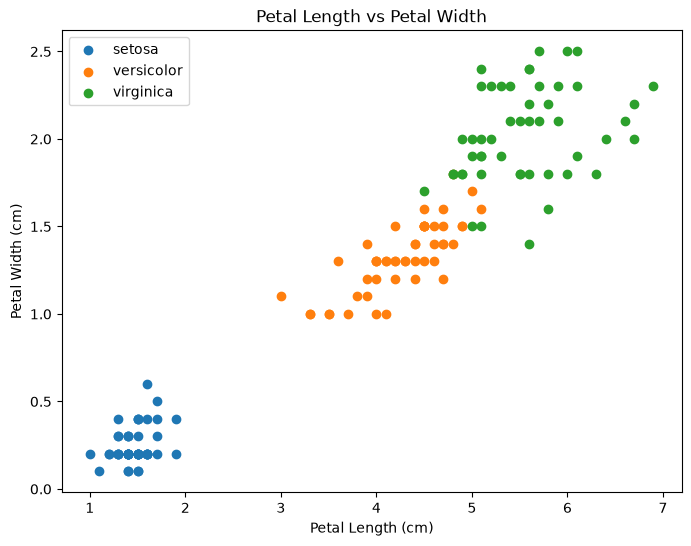

In [7]:
# Scatter plot: petal length vs petal width
plt.figure(figsize=(8, 6))

for species in df["species"].unique():
    subset = df[df["species"] == species]
    plt.scatter(
        subset["petal length (cm)"],
        subset["petal width (cm)"],
        label=species
    )

plt.xlabel("Petal Length (cm)")
plt.ylabel("Petal Width (cm)")
plt.title("Petal Length vs Petal Width")
plt.legend()
plt.show()


## 6. Prepare Input Features and Target

The model needs:

- `X`: input features
- `y`: target labels


In [8]:
# Input features
X = df[iris.feature_names]

# Target labels
y = df["species_id"]

print("Feature columns:")
print(X.columns)

print("\nTarget classes:")
print(iris.target_names)


Feature columns:
Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)'],
      dtype='str')

Target classes:
['setosa' 'versicolor' 'virginica']


## 7. Split the Data into Training and Testing Sets

We train the model using training data and evaluate it using test data.

Here, 80% of the data is used for training and 20% is used for testing.


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


Training samples: 120
Testing samples: 30


## 8. Scale the Features

Feature scaling helps many machine learning models perform better.

We use `StandardScaler` to transform the data so that each feature has a similar scale.


In [10]:
scaler = StandardScaler()

# Fit scaler only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data using the same scaler
X_test_scaled = scaler.transform(X_test)


## 9. Train the Machine Learning Model

We will use **Logistic Regression**, a common classification algorithm.


In [11]:
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train_scaled, y_train)

print("Model training complete.")


Model training complete.


## 10. Make Predictions on Test Data

In [12]:
# Predict species for the test set
y_pred = model.predict(X_test_scaled)

# Show actual vs predicted labels
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

results["Actual Species"] = results["Actual"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

results["Predicted Species"] = results["Predicted"].map({
    0: "setosa",
    1: "versicolor",
    2: "virginica"
})

results.head(10)


,Actual,Predicted,Actual Species,Predicted Species
0,0,0,setosa,setosa
1,2,2,virginica,virginica
2,1,1,versicolor,versicolor
3,1,1,versicolor,versicolor
4,0,0,setosa,setosa
5,1,1,versicolor,versicolor
6,0,0,setosa,setosa
7,0,0,setosa,setosa
8,2,2,virginica,virginica
9,1,1,versicolor,versicolor


## 11. Evaluate Model Accuracy

Accuracy tells us what percentage of test examples were classified correctly.


In [13]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Model Accuracy: {accuracy:.2f}")
print(f"Model Accuracy Percentage: {accuracy * 100:.2f}%")


Model Accuracy: 0.93
Model Accuracy Percentage: 93.33%


## 12. Confusion Matrix

A confusion matrix shows how many predictions were correct and incorrect for each class.


In [14]:
cm = confusion_matrix(y_test, y_pred)

cm_df = pd.DataFrame(
    cm,
    index=iris.target_names,
    columns=iris.target_names
)

cm_df


,setosa,versicolor,virginica
setosa,10,0,0
versicolor,0,9,1
virginica,0,1,9


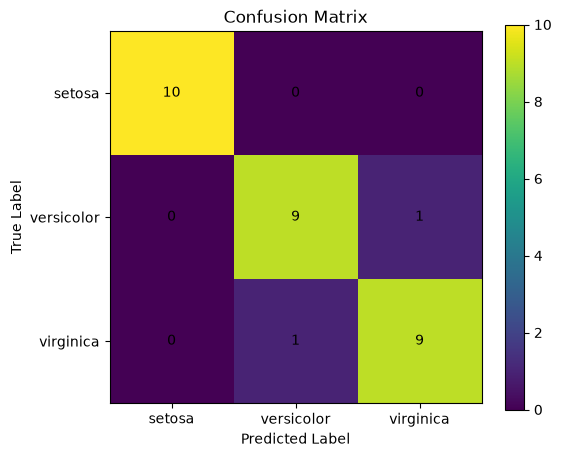

In [15]:
plt.figure(figsize=(6, 5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(ticks=np.arange(len(iris.target_names)), labels=iris.target_names)
plt.yticks(ticks=np.arange(len(iris.target_names)), labels=iris.target_names)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.show()


## 13. Classification Report

The classification report gives more detailed performance metrics:

- **Precision**: Out of all flowers predicted as a species, how many were correct?
- **Recall**: Out of all actual flowers of a species, how many were correctly found?
- **F1-score**: Balance between precision and recall.


In [16]:
print(classification_report(y_test, y_pred, target_names=iris.target_names))


              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



## 14. Test the Model with a New Flower

Now we can give the model new flower measurements and ask it to predict the species.


In [17]:
# Example new flower measurements:
# [sepal length, sepal width, petal length, petal width]
new_flower = np.array([[5.1, 3.5, 1.4, 0.2]])

# Scale the new flower using the same scaler
new_flower_scaled = scaler.transform(new_flower)

# Predict species
prediction = model.predict(new_flower_scaled)

print("Predicted species:", iris.target_names[prediction[0]])


Predicted species: setosa


C:\Users\gohar\miniconda3\envs\DataScience\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 15. Conclusion

In this notebook, we:

1. Loaded the Iris dataset using Scikit-learn.
2. Explored and visualized the data.
3. Split the data into training and testing sets.
4. Trained a Logistic Regression classification model.
5. Evaluated the model using accuracy, confusion matrix, and classification report.
6. Used the trained model to predict the species of a new Iris flower.

This is a simple example of a supervised machine learning classification task.
